Zad9 Dane jest równanie różniczkowe:

dy/dx = f(x,y) = ((x^2)*cosx + 2y) / x. 

Rozwiązać równanie ulepszoną metodą Eulera (patrz str1 w bieżącym pliku) z warunkiem początkowym y(π)=pi^2 dla przedziału x = [pi, 2pi]  z krokiem h = pi/10. Przedstaw rozwiązanie graficznie.

ULEPSZONA METODA EULERA (METODA HEUNA)
Równanie: dy/dx = (x² * cos(x) + 2y) / x
Warunek początkowy: y(3.1416) = 9.8696
Przedział: [3.1416, 6.2832]
Krok: h = 0.314159
  n            x               y           dy/dx              k1              k2
--------------------------------------------------------------------------------
  0     3.141593      9.86960440      3.14159265             ---             ---
  1     3.455752     10.83378472      2.98338604      3.14159265      2.99656993
  2     3.769911     11.80425350      3.21242877      2.98338604      3.19481010
  3     4.084070     12.91743349      3.92520790      3.21242877      3.87429511
  4     4.398230     14.33126770      5.15770683      3.92520790      5.07554023
  5     4.712389     16.20487900      6.87756425      5.15770683      6.77007316
  6     5.026548     18.67703990      8.98464689      6.87756425      8.86070085
  7     5.340708     21.84613290     11.32017744      8.98464689     11.19042574
  8     5.654867     25.

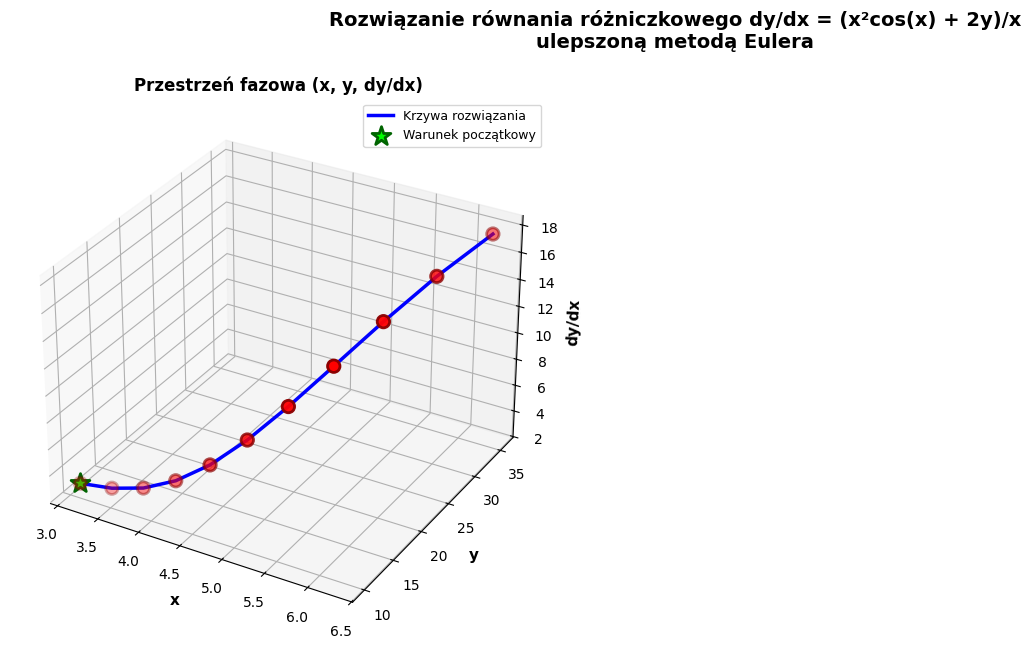


Wartość końcowa: y(6.283185) = 35.62241621
Pochodna końcowa: dy/dx(6.283185) = 17.62215256


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Definicja funkcji f(x, y)
def f(x, y):
    return (x**2 * np.cos(x) + 2*y) / x

# Ulepszona metoda Eulera (metoda Heuna)
def improved_euler(f, x0, y0, xn, h):
    """
    Rozwiązanie równania różniczkowego dy/dx = f(x,y) metodą Heuna
    
    Parametry:
    f - funkcja f(x,y)
    x0 - punkt początkowy x
    y0 - warunek początkowy y(x0)
    xn - punkt końcowy x
    h - krok
    """
    # Liczba kroków
    n = int((xn - x0) / h)
    
    # Tablice na wyniki
    x = np.zeros(n + 1)
    y = np.zeros(n + 1)
    
    # Warunki początkowe
    x[0] = x0
    y[0] = y0
    
    # Iteracja metodą Heuna
    for i in range(n):
        # Predyktor (metoda Eulera zwykła)
        k1 = f(x[i], y[i])
        y_pred = y[i] + h * k1
        
        # Korektor (średnia nachyleń)
        k2 = f(x[i] + h, y_pred)
        y[i + 1] = y[i] + h * (k1 + k2) / 2
        
        x[i + 1] = x[i] + h
    
    return x, y

# Parametry zadania
x0 = np.pi          # warunek początkowy x
y0 = np.pi**2       # warunek początkowy y(π) = π²
xn = 2 * np.pi      # koniec przedziału
h = np.pi / 10      # krok

# Rozwiązanie
x_values, y_values = improved_euler(f, x0, y0, xn, h)

# Wyświetlenie wyników w tabeli
print("Rozwiązanie równania dy/dx = (x²cos(x) + 2y)/x")
print("Ulepszoną metodą Eulera (metodą Heuna)")
print(f"Warunek początkowy: y({x0:.4f}) = {y0:.4f}")
print(f"Krok h = π/10 = {h:.4f}")
print("\n" + "="*50)
print(f"{'i':>3} | {'x':>10} | {'y':>15}")
print("="*50)

for i in range(len(x_values)):
    print(f"{i:3d} | {x_values[i]:10.6f} | {y_values[i]:15.6f}")

print("="*50)

# Wykres rozwiązania
plt.figure(figsize=(10, 6))
plt.plot(x_values, y_values, 'b-o', linewidth=2, markersize=6, label='Rozwiązanie numeryczne')
plt.grid(True, alpha=0.3)
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Rozwiązanie równania różniczkowego dy/dx = (x²cos(x) + 2y)/x\nUlepszona metoda Eulera', fontsize=14)
plt.legend(fontsize=11)

# Oznaczenie punktów charakterystycznych
plt.axvline(x=np.pi, color='r', linestyle='--', alpha=0.5, label=f'x₀ = π')
plt.axvline(x=2*np.pi, color='g', linestyle='--', alpha=0.5, label=f'xₙ = 2π')

# Dodanie etykiet osi z π
ax = plt.gca()
ax.set_xticks([np.pi, 1.5*np.pi, 2*np.pi])
ax.set_xticklabels(['π', '1.5π', '2π'])

plt.tight_layout()
plt.show()

# Dodatkowy wykres pokazujący nachylenie
plt.figure(figsize=(10, 6))
slopes = [f(x_values[i], y_values[i]) for i in range(len(x_values))]
plt.plot(x_values, slopes, 'r-o', linewidth=2, markersize=6)
plt.grid(True, alpha=0.3)
plt.xlabel('x', fontsize=12)
plt.ylabel("dy/dx", fontsize=12)
plt.title('Nachylenie funkcji dy/dx w punktach obliczeniowych', fontsize=14)

ax = plt.gca()
ax.set_xticks([np.pi, 1.5*np.pi, 2*np.pi])
ax.set_xticklabels(['π', '1.5π', '2π'])

plt.tight_layout()
plt.show()